# Alzheimer's MRI Classification -- Data Pipeline (Phase B)
Builds the subject manifest, does the subject-wise train/val/test split, and extracts axial MRI slices
from the raw ADNI DICOM volumes. Logic lives in `src/data_prep.py` -- this notebook just runs it and
shows the results.

This re-run uses an **extended slice height range** (0.28-0.48, was 0.28-0.42) to include the
hippocampus/medial temporal lobe -- the custom CNN baseline confused AD with CN far more than expected,
and the original range stopped just short of that region.

## 1. Imports

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import data_prep
from data_prep import build_manifest, split_subjects, process_all

print('AXIAL_ROW_RANGE:', data_prep.AXIAL_ROW_RANGE)
print('N_SLICES_PER_SUBJECT:', data_prep.N_SLICES_PER_SUBJECT)

AXIAL_ROW_RANGE: (0.28, 0.48)
N_SLICES_PER_SUBJECT: 32


## 2. Subject Manifest
Reusing the existing subject-level split from `data/subject_manifest.csv` (built in the first Phase B run) --
we want to keep the same train/val/test subject assignment for a fair before/after comparison, not re-roll it.

In [4]:
manifest = pd.read_csv('../data/subject_manifest.csv')
print(manifest.groupby(['split','class']).size().unstack())

class  AD  CN  EMCI  LMCI
split                    
test   11  15    21    19
train  54  68    98    87
val    12  14    21    19


## 3. Extract Slices (the long step -- watch the progress bar below)

In [5]:
slice_manifest = process_all(manifest, Path('../data/processed'), resume=True)
slice_manifest.to_csv('../data/manifest.csv', index=False)
print('Total images:', len(slice_manifest))
print(slice_manifest.groupby(['split','class']).size().unstack())

Extracting slices: 100%|██████████| 439/439 [55:24<00:00,  7.57s/it]

Total images: 14048
class    AD    CN  EMCI  LMCI
split                        
test    352   480   672   608
train  1728  2176  3136  2784
val     384   448   672   608


## 4. Sanity Check: Sample Slices Per Class

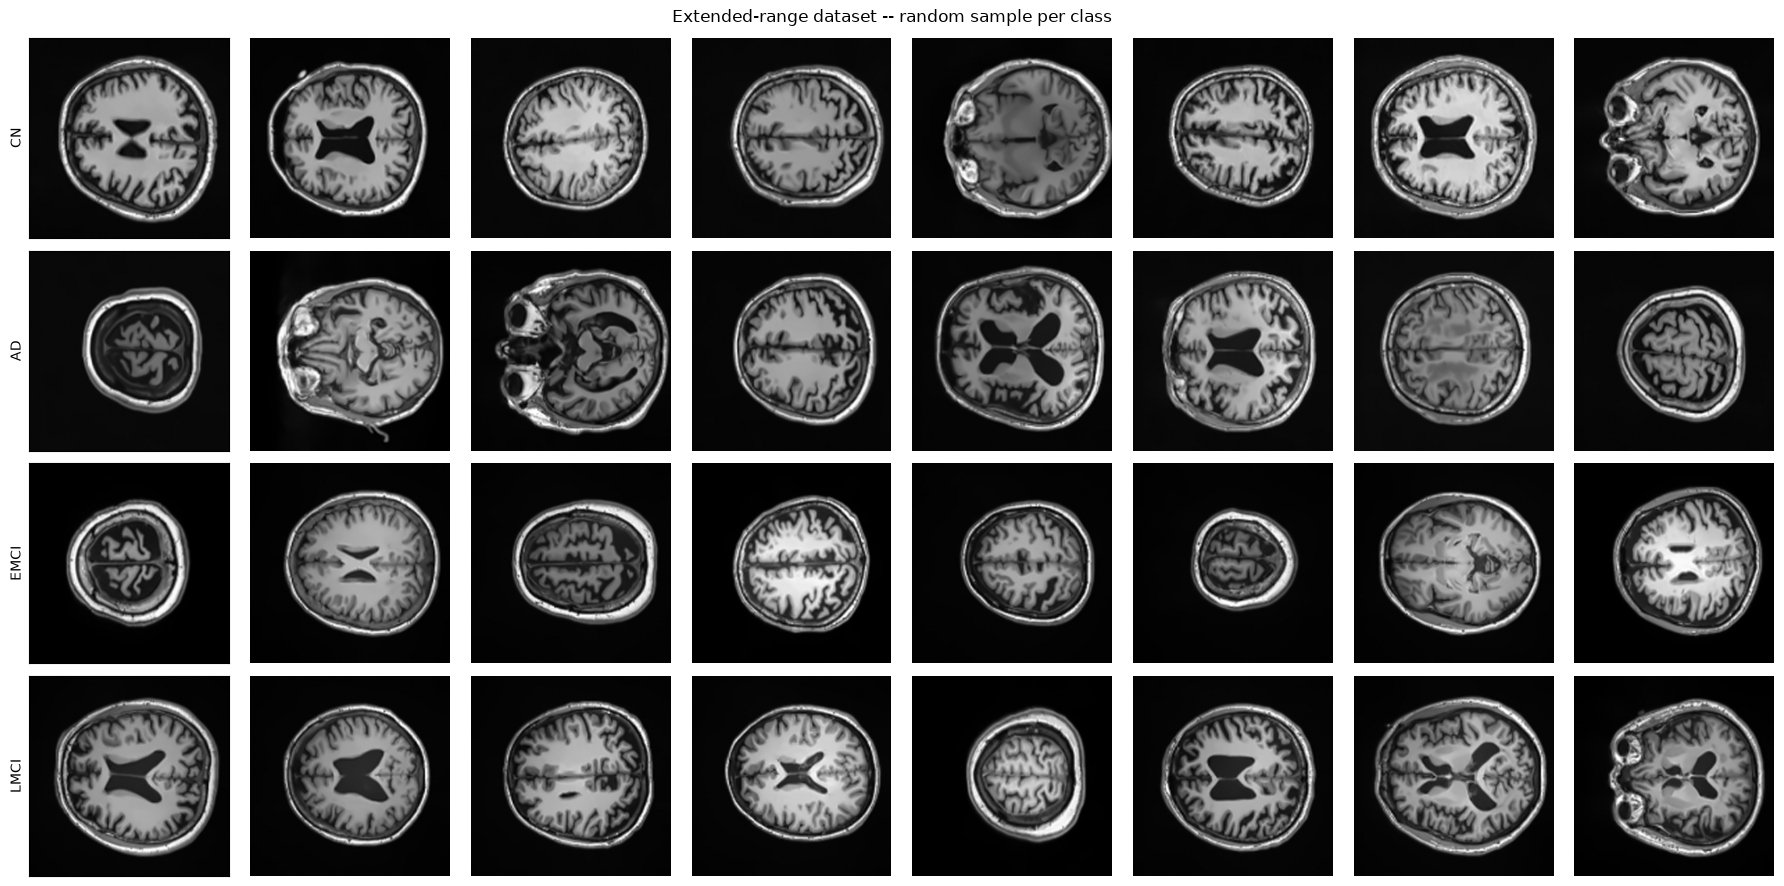

In [6]:
import cv2
CLASSES = ['CN', 'AD', 'EMCI', 'LMCI']
fig, axes = plt.subplots(len(CLASSES), 8, figsize=(18, 9))
for r, cls in enumerate(CLASSES):
    subset = slice_manifest[(slice_manifest['class']==cls) & (slice_manifest['split']=='train')]
    sample = subset.sample(8, random_state=7)
    for c, (_, row) in enumerate(sample.iterrows()):
        img = cv2.imread(row['filepath'], cv2.IMREAD_GRAYSCALE)
        axes[r,c].imshow(img, cmap='gray'); axes[r,c].axis('off')
        if c == 0:
            axes[r,c].set_ylabel(cls)
    axes[r,0].axis('on'); axes[r,0].set_xticks([]); axes[r,0].set_yticks([])
plt.suptitle('Extended-range dataset -- random sample per class')
plt.tight_layout()
plt.show()